# Predicting Adult Income with Random Forest

**Student Name:** Hansani J.A.T.H.

**IT Number:** IT25300345  
**Group ID:** 2026-Y2-S1-MLB-B1G1-07  
**Model:** Random Forest

---

This notebook evaluates Random Forest configurations for the Adult Income classification task. It compares different tree counts, tree depth, split/leaf settings, feature-selection settings, class-weight strategies, and a systematic `RandomizedSearchCV` configuration.

### How to use this notebook
1. Run the code cells in order, starting with Section 2.
2. Ensure `results/outputs/adult_processed.csv` is available; the setup cell checks several project-relative locations.
3. Review the comparison table, selected-model evaluation, feature importance, fairness check, and example prediction.

Charts are saved under `results/eda_visualizations/models`. Results can vary slightly depending on the prepared dataset and machine.

## 1. The task and the Random Forest idea

### What is being predicted?
The prepared Adult Income dataset contains census-related attributes. The target column is `income`, with two classes: `<=50K` and `>50K`. The Random Forest model uses the other columns to predict the target class.

### How does Random Forest make a prediction?
Random Forest is an ensemble of many decision trees. Each tree is trained using a different bootstrap sample of the training data and considers a subset of features when creating splits. The final prediction is obtained by combining the predictions of the individual trees.

Because multiple trees are combined, Random Forest can model non-linear relationships and feature interactions without requiring the user to manually create interaction terms.

### Why is Random Forest suitable here?
- The target is binary, which fits a classification forest.
- The model can capture non-linear relationships between income and attributes such as education, age, occupation, and hours worked.
- It can work directly with the already encoded numeric dataset, so feature scaling is not required.
- Feature importance values can be inspected to understand which input columns contribute most to the model.
- Class weighting can be tested because the `>50K` class is less common than the `<=50K` class.

## 2. Load the data and prepare a fair comparison

The setup cell loads the prepared CSV, separates `income` from the input features, and creates an 80/20 stratified train/test split. The same split is used across all Random Forest variants so the comparison is consistent.

Cross-validation is performed only on the training data. The test set is used for reporting the performance of each variant.

In [ ]:
import os
from pathlib import Path
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42

# Resolve the processed dataset from multiple project locations so "Run All" works
# even when VS Code launches the notebook from a different working directory.
project_root_candidates = []
for base in [os.getcwd(), os.path.dirname(os.getcwd()), os.path.dirname(os.path.dirname(os.getcwd()))]:
    project_root_candidates.append(base)
    project_root_candidates.extend([
        os.path.join(base, 'predicting-adult-income-level'),
        os.path.join(base, 'AI Project'),
        os.path.join(base, 'project')
    ])

seen = set()
project_roots = []
for root in project_root_candidates:
    resolved = os.path.abspath(root)
    if resolved not in seen:
        seen.add(resolved)
        project_roots.append(resolved)

raw_candidates = []
for root in project_roots:
    raw_candidates.extend([
        os.path.join(root, 'results', 'outputs', 'adult_processed.csv'),
        os.path.join(root, 'notebooks', 'results', 'outputs', 'adult_processed.csv'),
        os.path.join(root, 'notebooks', 'models', 'adult_processed.csv'),
        os.path.join(root, 'adult_processed.csv')
    ])

raw_candidates.extend([
    os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'results', 'outputs', 'adult_processed.csv')),
    os.path.normpath(os.path.join(os.getcwd(), '..', 'results', 'outputs', 'adult_processed.csv')),
    os.path.normpath(os.path.join(os.getcwd(), 'results', 'outputs', 'adult_processed.csv')),
    os.path.normpath(os.path.join(os.getcwd(), 'adult_processed.csv'))
])
DATA_PATH = next((candidate for candidate in raw_candidates if os.path.exists(candidate)), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "adult_processed.csv was not found. Place it in results/outputs/ or update DATA_PATH in this cell."
    )

df = pd.read_csv(DATA_PATH)

print(f"Loaded dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
display(df.head())

if 'income' not in df.columns:
    raise ValueError("The dataset must contain an 'income' target column.")

X = df.drop(columns=['income'])
y = df['income'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}")
print(f"Positive class (>50K) prevalence: {y.mean():.2%}")
print("\nClass counts:")
print(y.value_counts().rename({0: '<=50K', 1: '>50K'}))


Loaded dataset: 32,058 rows, 83 columns


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,1.360450,1.712817,-0.41443,-0.232725,5.989283,-0.008462,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,-1.356863,-0.310543,-0.02313,-0.232725,5.989283,-2.567806,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,-0.402131,0.935970,-0.41443,-0.232725,5.989283,3.745241,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,-0.622454,0.637500,-0.02313,-0.232725,5.989283,-0.008462,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0.111955,0.928000,1.15077,-0.232725,5.989283,0.674029,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


Train size: 25,646 | Test size: 6,412
Positive class (>50K) prevalence: 23.48%

Class counts:
income
<=50K    24532
>50K      7526
Name: count, dtype: int64


## 3. How model performance is measured

The target classes are imbalanced, so accuracy is not used alone.

- **Accuracy:** Overall proportion of correct predictions.
- **Precision:** Of the people predicted as `>50K`, how many are actually `>50K`?
- **Recall:** Of the people actually in the `>50K` class, how many are identified?
- **F1-score:** Harmonic mean of precision and recall; this is the main comparison metric.
- **ROC-AUC:** Measures ranking quality across classification thresholds.
- **Inference time:** Approximate time required to predict the test set on the current machine.

Five-fold stratified cross-validation is run on the training data. Test metrics are also reported for every variant. The same test set is used for the experiment comparison, so the comparison should not be treated as a completely untouched final estimate.

In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

# RANDOM_STATE is normally defined in the setup cell (Section 2); fall back if it was skipped
try:
    RANDOM_STATE
except NameError:
    RANDOM_STATE = 42

rf_results = []

def evaluate_rf_variant(name, model, X_tr, y_tr, X_te, y_te,
                        preprocessing_desc, hyperparams_desc):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    start = time.time()
    cv_scores = cross_validate(
        model,
        X_tr,
        y_tr,
        cv=cv,
        scoring=['f1', 'precision', 'recall', 'roc_auc'],
        n_jobs=-1
    )
    cv_elapsed = time.time() - start

    model.fit(X_tr, y_tr)

    pred_start = time.time()
    y_pred = model.predict(X_te)
    pred_time = time.time() - pred_start

    y_prob = model.predict_proba(X_te)[:, 1]

    row = {
        'Variant': name,
        'Preprocessing': preprocessing_desc,
        'Hyperparameters': hyperparams_desc,
        'CV 5-Fold F1': round(cv_scores['test_f1'].mean(), 4),
        'CV 5-Fold AUC': round(cv_scores['test_roc_auc'].mean(), 4),
        'Test Accuracy': round(accuracy_score(y_te, y_pred), 4),
        'Test Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Test Recall': round(recall_score(y_te, y_pred, zero_division=0), 4),
        'Test F1-Score': round(f1_score(y_te, y_pred, zero_division=0), 4),
        'Test ROC-AUC': round(roc_auc_score(y_te, y_prob), 4),
        'Inference Time (s)': round(pred_time, 4),
        'CV Time (s)': round(cv_elapsed, 2)
    }

    rf_results.append(row)

    print(
        f"[{name}] CV F1={row['CV 5-Fold F1']:.4f} | "
        f"Test F1={row['Test F1-Score']:.4f} | "
        f"Test Recall={row['Test Recall']:.4f} | "
        f"Test AUC={row['Test ROC-AUC']:.4f} | "
        f"Inference={row['Inference Time (s)']:.4f}s"
    )

    return model, y_pred, y_prob, row


## 4. Compare 10 Random Forest configurations

The following variants intentionally change one or more Random Forest settings so the effect can be compared on the same dataset.

| Variant | Main change |
| --- | --- |
| V1 | Baseline Random Forest with 200 trees |
| V2 | Larger forest with 500 trees |
| V3 | Shallow trees with `max_depth=10` |
| V4 | Deeper trees with `max_depth=30` |
| V5 | Larger minimum split size (`min_samples_split=10`) |
| V6 | Larger minimum leaf size (`min_samples_leaf=4`) |
| V7 | `class_weight='balanced'` for class imbalance |
| V8 | `class_weight='balanced_subsample'` |
| V9 | `sqrt` feature selection per split with 500 trees and balanced weighting |
| V10 | `RandomizedSearchCV` tuned Random Forest using five-fold CV F1-score |

Random Forest does not require standardisation or normalisation because its tree split rules are based on feature thresholds rather than distance calculations.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Variant 1: Baseline Random Forest
v1_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf1, p1, pr1, r1 = evaluate_rf_variant(
    "V1: Baseline (200 trees)",
    v1_rf, X_train, y_train, X_test, y_test,
    "Raw prepared features (no scaling required)",
    "n_estimators=200, max_depth=None, class_weight=None"
)

[V1: Baseline (200 trees)] CV F1=0.6704 | Test F1=0.6567 | Test Recall=0.6000 | Test AUC=0.9051 | Inference=0.0941s


In [ ]:
# Variant 2: Larger forest
v2_rf = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf2, p2, pr2, r2 = evaluate_rf_variant(
    "V2: More Trees (500)",
    v2_rf, X_train, y_train, X_test, y_test,
    "Raw prepared features",
    "n_estimators=500, max_depth=None, class_weight=None"
)

[V2: More Trees (500)] CV F1=0.6721 | Test F1=0.6613 | Test Recall=0.6033 | Test AUC=0.9066 | Inference=0.1639s


In [ ]:
# Variant 3: Shallow trees
v3_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf3, p3, pr3, r3 = evaluate_rf_variant(
    "V3: Shallow Trees (depth=10)",
    v3_rf, X_train, y_train, X_test, y_test,
    "Raw prepared features",
    "n_estimators=300, max_depth=10, class_weight=None"
)

[V3: Shallow Trees (depth=10)] CV F1=0.6371 | Test F1=0.6197 | Test Recall=0.5030 | Test AUC=0.9110 | Inference=0.1001s


In [ ]:
# Variant 4: Deeper trees
v4_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf4, p4, pr4, r4 = evaluate_rf_variant(
    "V4: Deeper Trees (depth=30)",
    v4_rf, X_train, y_train, X_test, y_test,
    "Raw prepared features",
    "n_estimators=300, max_depth=30, class_weight=None"
)

[V4: Deeper Trees (depth=30)] CV F1=0.6750 | Test F1=0.6654 | Test Recall=0.5927 | Test AUC=0.9126 | Inference=0.1209s


In [ ]:
# Variant 5: Larger minimum split size
v5_rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf5, p5, pr5, r5 = evaluate_rf_variant(
    "V5: Larger min split (10)",
    v5_rf, X_train, y_train, X_test, y_test,
    "Raw prepared features",
    "n_estimators=300, min_samples_split=10"
)

[V5: Larger min split (10)] CV F1=0.6821 | Test F1=0.6689 | Test Recall=0.5980 | Test AUC=0.9139 | Inference=0.1431s


In [ ]:
# Variant 6: Larger minimum leaf size
v6_rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=4,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf6, p6, pr6, r6 = evaluate_rf_variant(
    "V6: Larger min leaf (4)",
    v6_rf, X_train, y_train, X_test, y_test,
    "Raw prepared features",
    "n_estimators=300, min_samples_leaf=4"
)

[V6: Larger min leaf (4)] CV F1=0.6654 | Test F1=0.6574 | Test Recall=0.5635 | Test AUC=0.9172 | Inference=0.1638s


In [ ]:
# Variant 7: Balanced class weights
v7_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf7, p7, pr7, r7 = evaluate_rf_variant(
    "V7: Balanced Class Weight",
    v7_rf, X_train, y_train, X_test, y_test,
    "Raw prepared features",
    "n_estimators=300, class_weight='balanced'"
)

[V7: Balanced Class Weight] CV F1=0.6897 | Test F1=0.6895 | Test Recall=0.7236 | Test AUC=0.9052 | Inference=0.1487s


In [ ]:
# Variant 8: Balanced subsample class weighting
v8_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf8, p8, pr8, r8 = evaluate_rf_variant(
    "V8: Balanced Subsample",
    v8_rf, X_train, y_train, X_test, y_test,
    "Raw prepared features",
    "n_estimators=300, class_weight='balanced_subsample'"
)

[V8: Balanced Subsample] CV F1=0.6650 | Test F1=0.6574 | Test Recall=0.5940 | Test AUC=0.9056 | Inference=0.1555s


In [ ]:
# Variant 9: Many trees + sqrt feature selection + balanced weights
v9_rf = RandomForestClassifier(
    n_estimators=500,
    max_features='sqrt',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf9, p9, pr9, r9 = evaluate_rf_variant(
    "V9: 500 Trees + sqrt + balanced",
    v9_rf, X_train, y_train, X_test, y_test,
    "Raw prepared features",
    "n_estimators=500, max_features='sqrt', class_weight='balanced'"
)

[V9: 500 Trees + sqrt + balanced] CV F1=0.6905 | Test F1=0.6882 | Test Recall=0.7229 | Test AUC=0.9055 | Inference=0.3013s


In [ ]:
# Variant 10: Systematic RandomizedSearchCV tuning
param_dist = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': [None, 'balanced', 'balanced_subsample'],
    'criterion': ['gini', 'entropy']
}

print("Tuning Random Forest with 5-Fold Stratified RandomizedSearchCV...")

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

rf_search.fit(X_train, y_train)

print("Best Parameters:")
print(rf_search.best_params_)
print(f"Best 5-Fold CV F1 Score: {rf_search.best_score_:.4f}")

rf10, p10, pr10, r10 = evaluate_rf_variant(
    "V10: RandomizedSearchCV Optimal",
    rf_search.best_estimator_,
    X_train, y_train, X_test, y_test,
    "Raw prepared features",
    str(rf_search.best_params_)
)

best_rf = rf10


Tuning Random Forest with 5-Fold Stratified RandomizedSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


Best Parameters:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'gini', 'class_weight': 'balanced_subsample'}
Best 5-Fold CV F1 Score: 0.7046


[V10: RandomizedSearchCV Optimal] CV F1=0.7046 | Test F1=0.7008 | Test Recall=0.7276 | Test AUC=0.9140 | Inference=0.1836s


## 5. Read the comparison table and chart

The table is sorted by test F1-score. The chart compares test F1-score and ROC-AUC across the ten configurations.

The model with the best test F1-score is the best-performing variant **on this particular test split**. Separately, V10 is the model selected by `RandomizedSearchCV` using training-set cross-validation. These two choices can differ.


=================== RANDOM FOREST PERFORMANCE COMPARISON ===================


,Variant,Preprocessing,Hyperparameters,CV 5-Fold F1,CV 5-Fold AUC,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Test ROC-AUC,Inference Time (s),CV Time (s)
0,V10: RandomizedSearchCV Optimal,Raw prepared features,"{'n_estimators': 300, 'min_samples_split': 10,...",0.7046,0.9134,0.8542,0.6759,0.7276,0.7008,0.9140,0.1836,8.03
1,V7: Balanced Class Weight,Raw prepared features,"n_estimators=300, class_weight='balanced'",0.6897,0.9053,0.8470,0.6584,0.7236,0.6895,0.9052,0.1487,6.32
2,V9: 500 Trees + sqrt + balanced,Raw prepared features,"n_estimators=500, max_features='sqrt', class_w...",0.6905,0.9054,0.8462,0.6566,0.7229,0.6882,0.9055,0.3013,11.56
3,V5: Larger min split (10),Raw prepared features,"n_estimators=300, min_samples_split=10",0.6821,0.9137,0.8610,0.7589,0.5980,0.6689,0.9139,0.1431,5.15
4,V4: Deeper Trees (depth=30),Raw prepared features,"n_estimators=300, max_depth=30, class_weight=None",0.6750,0.9118,0.8601,0.7585,0.5927,0.6654,0.9126,0.1209,7.49
5,V2: More Trees (500),Raw prepared features,"n_estimators=500, max_depth=None, class_weight...",0.6721,0.9056,0.8550,0.7317,0.6033,0.6613,0.9066,0.1639,13.93
6,V8: Balanced Subsample,Raw prepared features,"n_estimators=300, class_weight='balanced_subsa...",0.6650,0.9053,0.8546,0.7358,0.5940,0.6574,0.9056,0.1555,6.90
7,V6: Larger min leaf (4),Raw prepared features,"n_estimators=300, min_samples_leaf=4",0.6654,0.9162,0.8621,0.7888,0.5635,0.6574,0.9172,0.1638,4.77
8,V1: Baseline (200 trees),Raw prepared features (no scaling required),"n_estimators=200, max_depth=None, class_weight...",0.6704,0.9046,0.8528,0.7253,0.6000,0.6567,0.9051,0.0941,9.65
9,V3: Shallow Trees (depth=10),Raw prepared features,"n_estimators=300, max_depth=10, class_weight=None",0.6371,0.9119,0.8551,0.8070,0.5030,0.6197,0.9110,0.1001,6.51


Saved comparison plot to: C:\Users\Malan\Documents\Academic\Y2S1\AIML\AI Project\predicting-adult-income-level\results\eda_visualizations\models\IT25300345_RandomForest_varieties_comparison.png


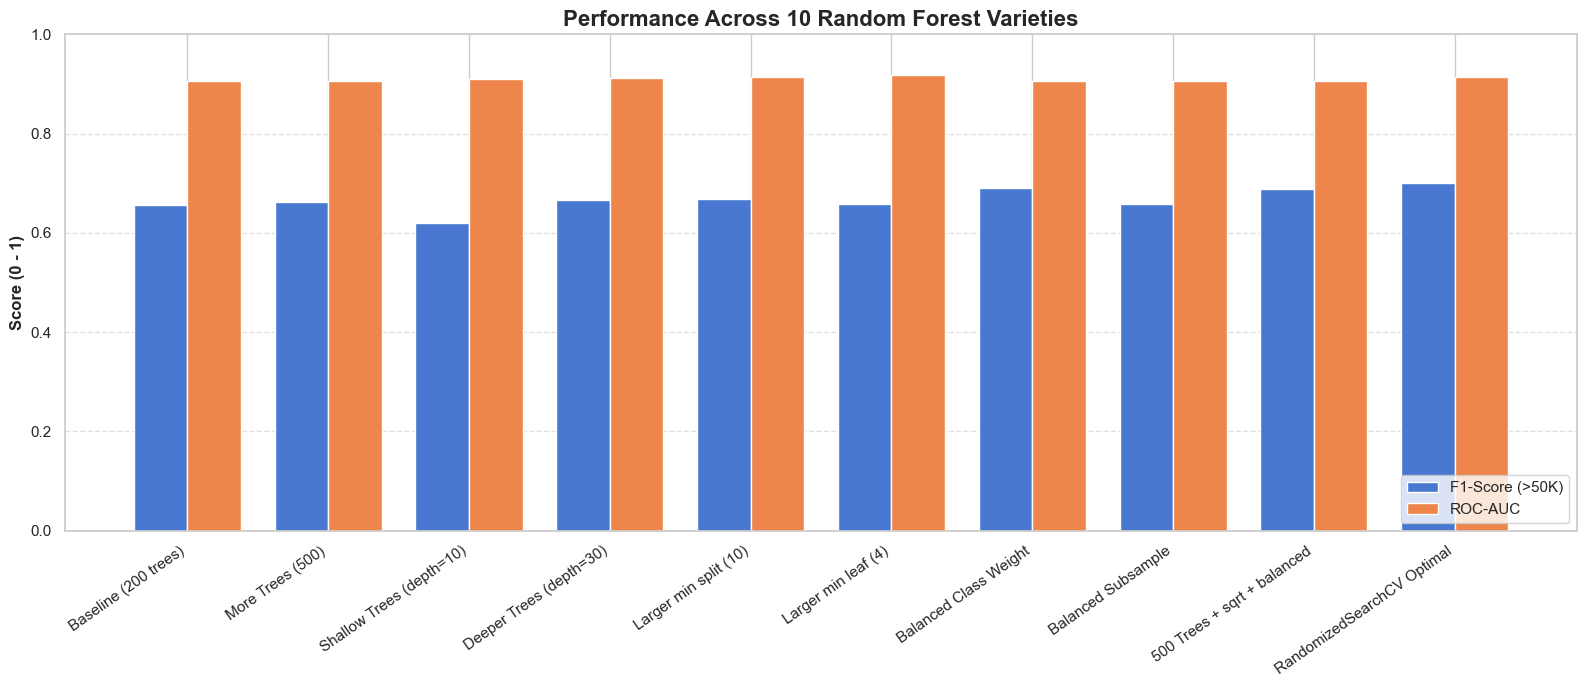

In [ ]:
results_df = pd.DataFrame(rf_results).sort_values(
    by='Test F1-Score', ascending=False
).reset_index(drop=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1200)

print("\n=================== RANDOM FOREST PERFORMANCE COMPARISON ===================")
display(results_df)

comparison_df = pd.DataFrame(rf_results).copy()
comparison_df['_variant_order'] = comparison_df['Variant'].str.extract(r'^V(\d+)').astype(int)
comparison_df = comparison_df.sort_values('_variant_order').reset_index(drop=True)

variant_labels = comparison_df['Variant'].str.replace(
    r'^V\d+:\s*', '', regex=True
)

fig, ax = plt.subplots(figsize=(16, 7))
x = np.arange(len(comparison_df))
bar_width = 0.38

ax.bar(
    x - bar_width / 2,
    comparison_df['Test F1-Score'],
    bar_width,
    label='F1-Score (>50K)'
)
ax.bar(
    x + bar_width / 2,
    comparison_df['Test ROC-AUC'],
    bar_width,
    label='ROC-AUC'
)

ax.set_title(
    'Performance Across 10 Random Forest Varieties',
    fontsize=16,
    weight='bold'
)
ax.set_ylabel('Score (0 - 1)', fontsize=12, weight='bold')
ax.set_xticks(x, variant_labels, rotation=35, ha='right')
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.legend(loc='lower right')

comparison_output_dir = (
    Path(DATA_PATH).resolve().parents[2]
    / 'results' / 'eda_visualizations' / 'models'
)
comparison_output_dir.mkdir(parents=True, exist_ok=True)

comparison_output_path = (
    comparison_output_dir / 'IT25300345_RandomForest_varieties_comparison.png'
)

fig.tight_layout()
fig.savefig(comparison_output_path, dpi=300, bbox_inches='tight')
print(f"Saved comparison plot to: {comparison_output_path}")

plt.show()
plt.close(fig)


## 6. Detailed evaluation of the RandomizedSearchCV-selected model

This section evaluates V10, the estimator selected by `RandomizedSearchCV` according to cross-validation F1-score.

The three-panel figure shows:
1. **Confusion matrix** — counts of correct and incorrect class predictions.
2. **ROC curve** — ranking performance over different probability thresholds.
3. **Precision-Recall curve** — the trade-off involved in identifying the `>50K` class.

The feature-importance chart that follows shows the input variables that contribute most strongly to the fitted forest according to impurity-based importance.

Saved Random Forest evaluation plot to: C:\Users\Malan\Documents\Academic\Y2S1\AIML\AI Project\predicting-adult-income-level\results\eda_visualizations\models\IT25300345_RandomForest_ConfusionMatrix_ROC_PR.png


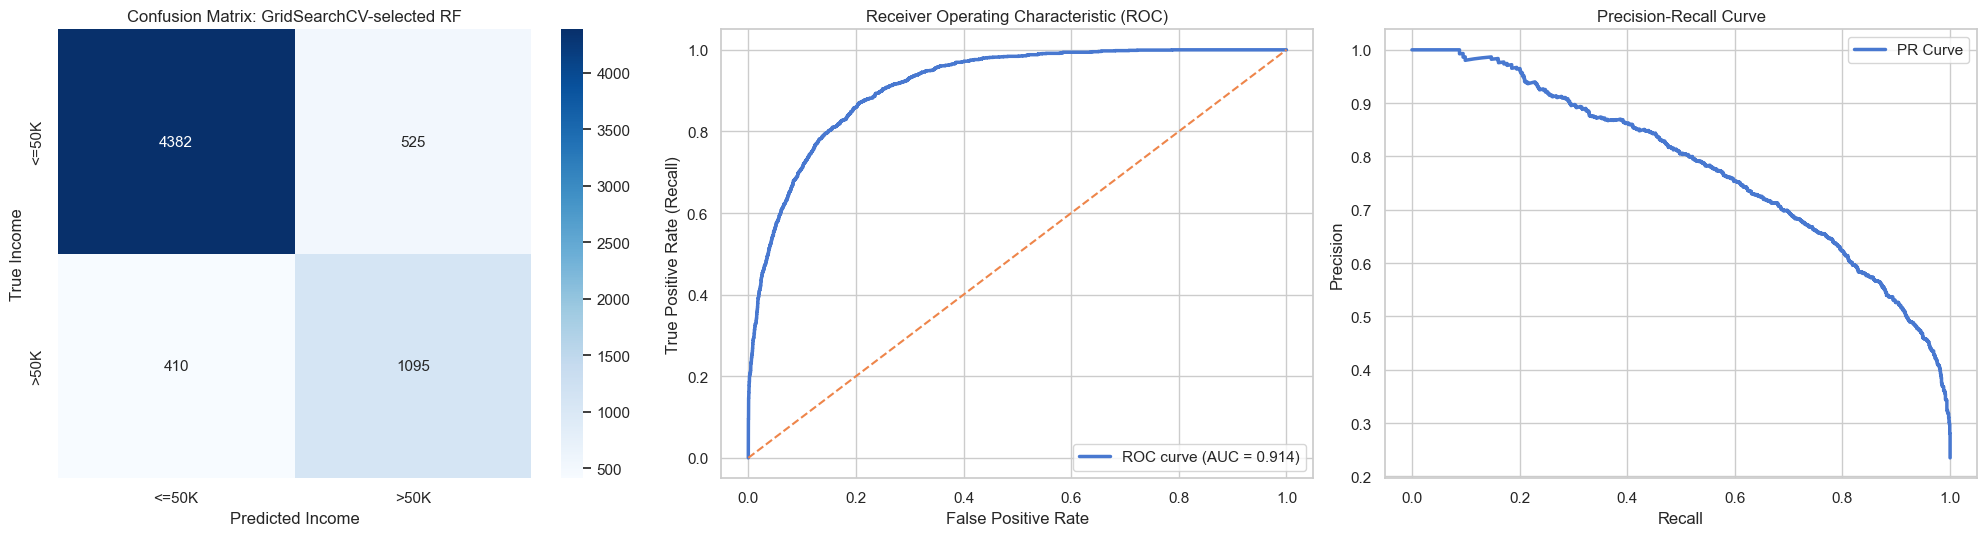


Classification Report for Random Forest:
              precision    recall  f1-score   support

       <=50K     0.9144    0.8930    0.9036      4907
        >50K     0.6759    0.7276    0.7008      1505

    accuracy                         0.8542      6412
   macro avg     0.7952    0.8103    0.8022      6412
weighted avg     0.8585    0.8542    0.8560      6412



In [ ]:
best_rf = rf_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
    xticklabels=['<=50K', '>50K'],
    yticklabels=['<=50K', '>50K']
)
axes[0].set_title('Confusion Matrix: RandomizedSearchCV-selected RF')
axes[0].set_xlabel('Predicted Income')
axes[0].set_ylabel('True Income')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
auc_value = roc_auc_score(y_test, y_prob_best)

axes[1].plot(
    fpr,
    tpr,
    lw=2.5,
    label=f'ROC curve (AUC = {auc_value:.3f})'
)
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Receiver Operating Characteristic (ROC)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].legend(loc='lower right')

# 3. Precision-Recall Curve
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_best)
axes[2].plot(
    rec_curve,
    prec_curve,
    lw=2.5,
    label='PR Curve'
)
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend(loc='upper right')

output_dir = (
    Path(DATA_PATH).resolve().parents[2]
    / 'results' / 'eda_visualizations' / 'models'
)
output_dir.mkdir(parents=True, exist_ok=True)

output_path = (
    output_dir / 'IT25300345_RandomForest_ConfusionMatrix_ROC_PR.png'
)

plt.tight_layout()
fig.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Saved Random Forest evaluation plot to: {output_path}")

plt.show()

print("\nClassification Report for Random Forest:")
print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=['<=50K', '>50K'],
        digits=4
    )
)


Saved feature-importance plot to: C:\Users\Malan\Documents\Academic\Y2S1\AIML\AI Project\predicting-adult-income-level\results\eda_visualizations\models\IT25300345_RandomForest_FeatureImportance.png


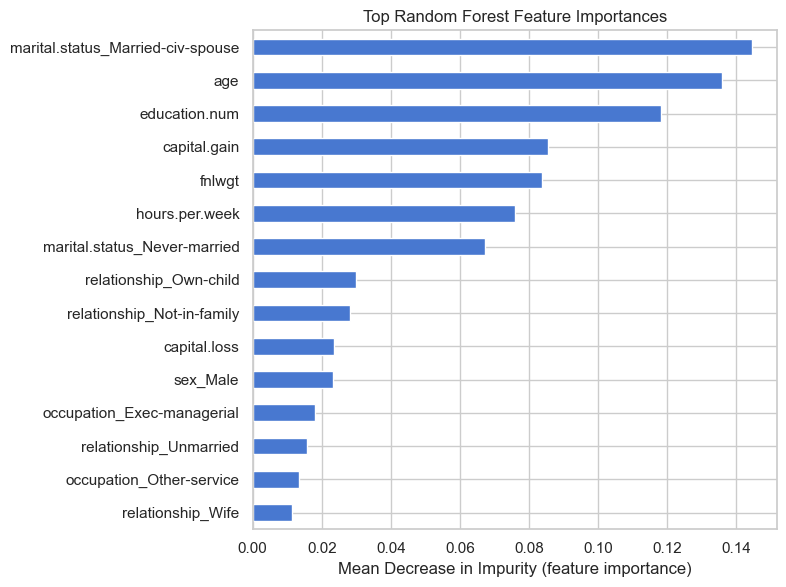

In [ ]:
# Feature importance from the selected Random Forest
importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_n = min(15, len(importance))
top_importance = importance.head(top_n).sort_values()

plt.figure(figsize=(8, 6))
top_importance.plot(kind='barh')
plt.title('Top Random Forest Feature Importances')
plt.xlabel('Mean Decrease in Impurity (feature importance)')
plt.tight_layout()

importance_output_path = (
    output_dir / 'IT25300345_RandomForest_FeatureImportance.png'
)
plt.savefig(importance_output_path, dpi=300, bbox_inches='tight')
print(f"Saved feature-importance plot to: {importance_output_path}")

plt.show()


## 7. Compare performance by sex (a limited fairness check)

When the preprocessed dataset contains the one-hot encoded `sex_Male` column, this section reports recall and F1-score separately for male and female test-set groups.

This is a descriptive comparison only. A difference between groups does not by itself prove unfairness or explain its cause. A full fairness assessment would require additional group metrics and an investigation of the underlying data.

In [ ]:
if 'sex_Male' in X_test.columns:
    test_eval = X_test.copy()
    test_eval['True'] = y_test.to_numpy()
    test_eval['Pred'] = y_pred_best

    male_mask = test_eval['sex_Male'] == 1
    female_mask = test_eval['sex_Male'] == 0

    print("=== GENDER FAIRNESS METRICS (RANDOM FOREST) ===")

    if male_mask.sum() > 0:
        print(
            f"Male Population   (n={male_mask.sum():,}): "
            f"Recall={recall_score(y_test[male_mask], y_pred_best[male_mask], zero_division=0):.4f}, "
            f"F1={f1_score(y_test[male_mask], y_pred_best[male_mask], zero_division=0):.4f}"
        )

    if female_mask.sum() > 0:
        print(
            f"Female Population (n={female_mask.sum():,}): "
            f"Recall={recall_score(y_test[female_mask], y_pred_best[female_mask], zero_division=0):.4f}, "
            f"F1={f1_score(y_test[female_mask], y_pred_best[female_mask], zero_division=0):.4f}"
        )
else:
    print("The column 'sex_Male' is not present in the prepared dataset.")
    print("The group-level sex comparison cannot be performed with this dataset.")


=== GENDER FAIRNESS METRICS (RANDOM FOREST) ===
Male Population   (n=4,301): Recall=0.7411, F1=0.7072
Female Population (n=2,111): Recall=0.6484, F1=0.6605


## 8. See one prediction

This cell uses one fixed row from the test set and displays selected feature values, the true income label, the predicted label, and the predicted probability of `>50K`.

The input values are taken from the processed dataset, so categorical values may already be represented by one-hot encoded columns.

In [ ]:
sample_idx = 15

if sample_idx >= len(X_test):
    raise IndexError(f"sample_idx must be between 0 and {len(X_test)-1}.")

sample_x = X_test.iloc[[sample_idx]]
true_label = y_test.iloc[sample_idx]
predicted_label = best_rf.predict(sample_x)[0]
pred_prob = best_rf.predict_proba(sample_x)[0][1]

print("=== LIVE VIVA INFERENCE DEMO (RANDOM FOREST) ===")
print(f"Query Sample Index: {sample_idx}")

for feature in ['age', 'education.num', 'hours.per.week']:
    if feature in sample_x.columns:
        print(f"{feature}: {sample_x[feature].iloc[0]}")

print(f"True Income:       {'>50K' if true_label == 1 else '<=50K'}")
print(f"Predicted Income:  {'>50K' if predicted_label == 1 else '<=50K'}")
print(f"Predicted Probability of >50K: {pred_prob * 100:.2f}%")
print("Demonstration status: Ready for viva assessment!")


=== LIVE VIVA INFERENCE DEMO (RANDOM FOREST) ===
Query Sample Index: 15
age: -0.6958946411174584
education.num: 1.5420700453127885
hours.per.week: -0.8615768547252523
True Income:       <=50K
Predicted Income:  <=50K
Predicted Probability of >50K: 27.03%
Demonstration status: Ready for viva assessment!


## 9. Save the model and final takeaways

### 9.1 Save the selected model

The tuned Random Forest can be saved with `joblib` so it can be reused later without retraining.

### 9.2 What to take away
Random Forest combines many decision trees and can capture non-linear relationships and feature interactions. Increasing the number of trees can improve stability, while tree-depth and minimum-sample settings control how complex individual trees become. Class weighting can change the balance between identifying the minority `>50K` class and avoiding false positives.

### 9.3 Limitations
- Random Forest can use substantial memory and training time when the number of trees is large.
- Impurity-based feature importance can favor some high-cardinality or continuous variables, so importance should not be interpreted as proof of causation.
- Class weighting changes the learning objective but does not remove the underlying class imbalance.
- The same test set is used to compare the ten variants, so the comparison is experimental rather than an independent final validation.
- Fairness analysis here is limited to sex-based recall and F1-score when the required encoded column is available.

### 9.4 Possible improvements
- Use nested cross-validation for stricter model-selection evaluation.
- Compare Random Forest with Extra Trees, Gradient Boosting, or other ensemble methods.
- Tune the probability threshold based on the business objective, such as prioritising recall or precision for the `>50K` class.
- Extend fairness analysis to additional groups and metrics.

In [ ]:
import joblib
from pathlib import Path

In [ ]:
# Save the Random Forest model selected by RandomizedSearchCV
model_output_dir = Path(DATA_PATH).resolve().parents[2] / "results" / "models"
model_output_dir.mkdir(parents=True, exist_ok=True)
model_output_path = model_output_dir / "IT25300345_Model_RandomForest.pkl"
joblib.dump(best_rf, model_output_path)

print(f"Saved model to: {model_output_path.resolve()}")

# Reload check
reloaded_model = joblib.load(model_output_path)
print("Reload check prediction:", reloaded_model.predict(X_test.iloc[:5]).tolist())


Saved model to: C:\Users\Malan\Documents\Academic\Y2S1\AIML\AI Project\predicting-adult-income-level\results\models\IT25300345_Model_RandomForest.pkl


Reload check prediction: [0, 0, 0, 0, 0]


In [ ]:
import json
from pathlib import Path

# Get predictions from the best Random Forest model
y_pred = best_rf.predict(X_test)

# Calculate evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred)
}

# ROC-AUC
if hasattr(best_rf, "predict_proba"):
    y_prob = best_rf.predict_proba(X_test)[:, 1]
    metrics["roc_auc"] = roc_auc_score(y_test, y_prob)

# Create JSON result
result = {
    "member_id": "IT25300345",
    "model": "RandomForest",
    "best_params": best_rf.get_params(),
    "metrics": metrics
}

# Save JSON file
output_dir = Path(DATA_PATH).resolve().parents[2] / "results" / "model_results"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "IT25300345.json"

with open(output_path, "w") as f:
    json.dump(result, f, indent=2)

print(f"JSON file saved to: {output_path.resolve()}")

JSON file saved to: C:\Users\Malan\Documents\Academic\Y2S1\AIML\AI Project\predicting-adult-income-level\results\model_results\IT25300345.json
